# Apply 1550 nm laser
work around 1556.005 to dont disturb usman


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


from osa import OSA
import time
import numpy as np
import matplotlib.pyplot as plt
import wshelper as wsh
import calibration
from wsapi import * 
from scipy.signal import find_peaks


def create_connect_waveshaper():
    wsh.createWS('./WS200224_4x16.wsconfig')
    wsh.connect()

def disconnect_delete_waveshaper():
    wsh.disconnect()
    wsh.deleteWS()

def apply_waveshaper_profile(comblines, peaks, phases, channels, delta_l=0.1, sigma=0.005, plot = False):
    """
    Function to apply a waveshaper profile based on the input parameters.

    Parameters:
    - comblines: List of center frequencies for the Gaussian signals.
    - peaks: List of peak amplitudes for the Gaussian signals.
    - phases: List of phases for the Gaussian signals.
    - channels: List of channel assignments for each signal.
    - delta_l: Offset for frequency range. Default is 0.4.
    - sigma: Standard deviation for Gaussian function. Default is 0.008.
    """
    
    # Step 1: Precompute THz values for comblines and precompute bounds for each combline
    combline_thz = [wsh.nm2thz(combline) for combline in comblines] 
    rang_min = [wsh.nm2thz(combline - delta_l) for combline in comblines]
    rang_max = [wsh.nm2thz(combline + delta_l) for combline in comblines]
    
    # Step 2: Calculate the overall frequency range in THz only once
    rang = (wsh.nm2thz(min(comblines)-0.3), wsh.nm2thz(max(comblines)+0.3))
    rang = (round(rang[0], 3), round(rang[1], 3))

    # Step 3: Generate the signal profile for each combline
    signal = tuple(
        wsh.BoundFunc(
            wsh.gaussian(mu=comb_thz, peak=peak, phase=phase, sigma=sigma),
            max_r, min_r, channel
        )
        for comb_thz, peak, phase, channel, min_r, max_r 
        in zip(combline_thz, peaks, phases, channels, rang_min, rang_max)
    )
    #print(f'the peaks are: {peaks}')
    
    # Step 4: Compose the profile
    new_profile = wsh.compose_func((0, 0, 0), rang[1], rang[0], 1e-3, *signal)
    
    # Step 5: Plot the generated attenuation profile
    if plot == True:        
        plt.plot(wsh.nm2thz(new_profile[:, 0]), -new_profile[:, 1])
        plt.xlabel('Wavelength (nm)')
        plt.ylabel('Attenuation')
        plt.title('Generated Profile')
        plt.show()

    wsh.apply_profile(new_profile)

    #Step 6: Apply missagh profile to waveshaper
    gaussian_wave = wsh.gaussian(mu=wsh.nm2thz(1552.4), peak=1, phase=0, sigma=0.4)  
    bound_gaussian = wsh.BoundFunc(gaussian_wave, wsh.nm2thz(1553.8), wsh.nm2thz(1551), 8)
    missagh_profile = wsh.compose_func((0, 0, 0), wsh.nm2thz(1553.8), wsh.nm2thz(1551), 1e-3, bound_gaussian)
    wsh.apply_profile(missagh_profile)  

class CustomLayer(nn.Module):
    def __init__(self, comblines):
        super(CustomLayer, self).__init__()
        # Initialize k as a trainable parameter with the same size as C
        self.phi = nn.Parameter(torch.zeros(len(comblines)))

    def forward(self, C):
        return self.physical_model(self.phi, C)
    
    def physical_model(self, phases, coefficients):
        N = coefficients.size(1)
        z = 1
        zero_tensor = torch.full((coefficients.size(0), 1), float(0), dtype=coefficients.dtype, device=coefficients.device)
        C = torch.cat((zero_tensor, coefficients), dim=1)

        k = torch.cat((torch.tensor([float(0)], dtype=phases.dtype, device=phases.device), phases))

        # Preallocate intensity tensor
        intensity = torch.zeros((coefficients.size(0), 2 * N + 1), dtype=torch.float, device=C.device)

        # Use vectorized operations where possible
        m_range = [torch.full((N-1, N-1), i, device=C.device) for i in torch.arange(2, 2 * N + 1)]
        # Separate odd and even tensors based on the integer value inside the tensor
        odd_m = [m for m in m_range if m[0, 0].item() % 2 == 1]
        even_m = [m for m in m_range if m[0, 0].item() % 2 == 0]

        js, ls = torch.meshgrid(torch.arange(1, N, device=C.device), torch.arange(1, N, device=C.device), indexing='ij')
        for m in odd_m:

            valid_indices = (0 < m - js) & (m - js <= N) & (0 < m - ls) & (m - ls <= N)

            j, l, m = js[valid_indices], ls[valid_indices], m[valid_indices]

            term = 4 * C[:, j] * C[:, m - j] * C[:, l] * C[:, m - l] * torch.exp(1j * (k[j] + k[m - j] - k[l] - k[m - l]) * z)
            intensity[:, m[0]] = term.sum(dim=1)
            #torch.cuda.memory._dump_snapshot("my_snapshot.pickle")

        for m in even_m:
            if m[0, 0] == 2 or m[0, 0] == 2 * N:
                intensity[:, m[0, 0]] = C[:, m[0, 0] // 2] ** 4
            else:
                valid_indices = (0 < m - js) & (m - js <= N) & (0 < m - ls) & (m - ls <= N)

                j, l, m = js[valid_indices], ls[valid_indices], m[valid_indices]

                exp_term = torch.exp(1j * (k[j] + k[m - j]) * z)
                middle_term = C[:, m // 2] ** 2 * torch.exp(1j * 2 * k[m // 2] * z)

                term1 = (2 * C[:, j] * C[:, m - j] * exp_term + middle_term).sum(dim=1)
                term2 = (2 * C[:, l] * C[:, m - l] * exp_term.conj() + middle_term.conj()).sum(dim=1)

                intensity[:, m[0]] = (term1 * term2).real
        
        return torch.abs(intensity[:, 2:2 * N + 1])


import os 

def create_folders(name):
    base_path = os.path.join("data_runs", name)
    stability_path = os.path.join(base_path, "stability")
    checkpoints_path = os.path.join(base_path, "checkpoints")
    traces_path = os.path.join(base_path, "traces")

    os.makedirs(stability_path, exist_ok=True)
    os.makedirs(checkpoints_path, exist_ok=True)
    os.makedirs(traces_path, exist_ok=True)

    print(f"Folders ensured:\n- {stability_path}\n- {checkpoints_path}\n- {traces_path}")


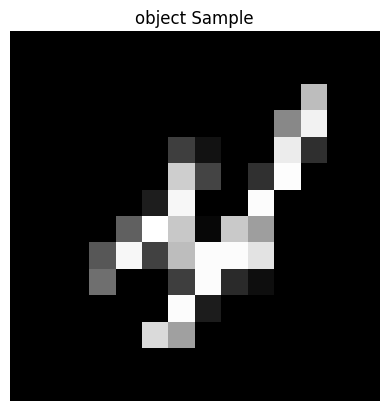

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from skimage.filters import threshold_otsu

# Custom transformation that applies Otsu's thresholding
class OtsuBinarize(object):
    def __call__(self, image):
        image_np = image.squeeze().numpy()
        thresh = threshold_otsu(image_np)
        binary_np = (image_np > thresh).astype(np.float32)
        return torch.from_numpy(binary_np).unsqueeze(0)

# Define the transformation pipeline
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((14, 14), interpolation=transforms.InterpolationMode.NEAREST) #OtsuBinarize(),transforms.Normalize(mean=[0.5], std=[0.5])
])

#train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
# Get indices for samples with label 4 ("object")
object_indices = [i for i, (_, label) in enumerate(train_dataset) if label == 3 or label == 4]

# Specify the number of object samples you want
n = 30#40  # replace with any number you desire

# Select the first n object indices
selected_object_indices = object_indices[:n]

# Create a subset of the dataset containing only the selected objects
object_dataset = Subset(train_dataset, selected_object_indices)

# Optionally, create a DataLoader for the subset
train_loader = DataLoader(object_dataset, batch_size=1, shuffle=True)

# Now, train_loader will yield batches containing only object images.

import matplotlib.pyplot as plt

# Extract one sample from the object_dataset
sample, label = object_dataset[2]

# Display the image
plt.imshow(sample.squeeze(), cmap='gray')
plt.title("object Sample")
plt.axis("off")
plt.show()


In [2]:
from pat import make_pat_func

# === Instantiate and connect OSA ===
host = '192.168.10.85'  # OSA IP address
port = 10001            # OSA port number
osa = OSA(host, port)
osa.connect()
response = osa.autenticate()
create_connect_waveshaper()

# Create a Model
n_comblines = [8, 32]
separation_comblines = 0.2
initial_wl = 1549.598-separation_comblines*8

comblines = [np.arange(initial_wl, initial_wl + i * separation_comblines, separation_comblines) for i in n_comblines]

peaks = [np.ones(n_comblines[i]) for i in range(len(n_comblines))]
channels = [np.ones(n_comblines[i]) for i in range(len(n_comblines))]
phases = [np.zeros(n_comblines[i]) for i in range(len(n_comblines))]
initrang = [122, 122]
finrang = [498, 600]
order = [9, 18]

wavelength_trim = []
poly = []
normalization = []
fraction_m_m = []

for i in range(len(n_comblines)):
    apply_waveshaper_profile(comblines[i], peaks[i], phases[i], channels[i], plot = False)
    wavelengths, power = osa.perform_measurement_OSA(np.mean(comblines[i]), (np.max(comblines[i])-np.mean(comblines[i]))*2+0.5, 0.02, sensitivity = "high3", resolution = 0.02)
    osa.plot_trace(wavelengths, power)

    # Perform calibration
    wavelength, power, polynomial = calibration.do_calibration(osa, center=np.mean(comblines[i])/2-0.1, span=(np.max(comblines[i])-np.mean(comblines[i]))+1, order = order[i], level=2, spacing='lin')
    poly.append(polynomial)
    powerfit = polynomial(wavelength)

    calibration.plot_polynomial_fit(wavelength[initrang[i]:finrang[i]], power[initrang[i]:finrang[i]], wavelength[initrang[i]:finrang[i]], powerfit[initrang[i]:finrang[i]], order=order[i])

    prominence = power - powerfit
    prominence = prominence[initrang[i]:finrang[i]]
    wavelength = wavelength[initrang[i]:finrang[i]]
    wavelength_trim.append(wavelength)
    max_indices, _ = find_peaks(prominence, distance=5, prominence=1e-8)
    print(f'number of maximum points {len(max_indices)}')
    max_x = np.array(wavelength)[max_indices]
    max_y = np.array(prominence)[max_indices]

    fraction_max_min = np.max(max_y)/(max_y[0])
    norm = 1/(fraction_max_min*max_y[0])
    normalization.append(norm)
    fraction_m_m.append(fraction_max_min)
    
    print(fraction_max_min)
    plt.plot(wavelength,prominence)
    plt.xlabel('Wavelenght')
    plt.ylabel('Amplitude')

NameError: name 'OSA' is not defined

In [ ]:
def lambda_m(lambda_1, delta_lambda, m):
    return 1 / ((2 / lambda_1) - (m - 1) * (abs(delta_lambda) / lambda_1**2))

# Example usage
delta_lambda = separation_comblines  # Example value in nm
m = [np.arange(1,2*n_comblines[i],1) for i in range(len(n_comblines))]  # Example mode number

targets = [lambda_m(initial_wl, delta_lambda, m[i])* 1e-9 for i in range(len(n_comblines))]
print(f"λ_m = {targets}")

max_indices = [[np.argmin(np.abs(wavelength_trim[j] - t)) for t in targets[j]] for j in range(len(n_comblines))]
print(f"Indices {max_indices}")

# Custom PyTorch layer
class WaveshaperLayer(nn.Module):
    def __init__(self, osa, comblines, channels, baseline, normalization, initrang, finrang, max_indices, delta_l=0.1, sigma=0.005):
        super(WaveshaperLayer, self).__init__()
        
        self.osa = osa
        self.comblines = comblines
        self.channels = channels
        self.baseline = baseline
        self.normalization = normalization
        self.delta_l = delta_l
        self.sigma = sigma
        self.initrang = initrang
        self.finrang = finrang
        self.max_indices = max_indices
        
        # Convert comblines to THz
        self.combline_thz = [wsh.nm2thz(combline) for combline in self.comblines]
        self.rang_min = [wsh.nm2thz(combline - delta_l) for combline in self.comblines]
        self.rang_max = [wsh.nm2thz(combline + delta_l) for combline in self.comblines]
        
        # Trainable phases
        self.phases = nn.Parameter(torch.zeros(len(self.comblines)))
        
    def forward(self, peaks):
        # Convert self.phases (tensor) to a NumPy array
        phases_slice = self.phases[:peaks.shape[0]]   
        phases_expressiveness = torch.dot(phases_slice, peaks)
        phase = self.phases.cpu().numpy() if torch.is_tensor(phases_expressiveness) else phases_expressiveness
        #phase = self.phases.cpu().numpy() if torch.is_tensor(phases_slice) else phases_slice

        # Generate signal profile for each combline
        #peaks = torch.abs(peaks) 
        apply_waveshaper_profile(self.comblines, peaks, phase, self.channels)

        wavelength, measurement = self.osa.perform_measurement_OSA(center=np.mean(self.comblines)/2-0.1, span=(np.max(self.comblines)-np.mean(self.comblines))+1, level=0.006, sensitivity = "high1", resolution = 0.02)
        # Use scipy's find_peaks to find local maxima in the inverted signal (i.e., local minima in original)
        prominence = measurement - self.baseline(wavelength)
        prominence = calibration.set_measurement_outside_range_to_zero(wavelength, prominence, (np.min(self.comblines)/2-0.3)*1e-9, (np.max(self.comblines)/2+0.3)*1e-9)
        prominence_trim = prominence[self.initrang:self.finrang]
        
        max_y = np.array(prominence_trim)[self.max_indices]
        max_y = max_y/(max_y[0]*self.normalization)
        # Convert max_y (NumPy array) back to a tensor
        max_y_tensor = torch.tensor(max_y, dtype=torch.float32)
        
        return max_y_tensor
    

λ_m = [array([7.73999000e-07, 7.74049003e-07, 7.74099013e-07, 7.74149029e-07,
       7.74199052e-07, 7.74249081e-07, 7.74299116e-07, 7.74349158e-07,
       7.74399207e-07, 7.74449262e-07, 7.74499323e-07, 7.74549391e-07,
       7.74599465e-07, 7.74649546e-07, 7.74699634e-07]), array([7.73999000e-07, 7.74049003e-07, 7.74099013e-07, 7.74149029e-07,
       7.74199052e-07, 7.74249081e-07, 7.74299116e-07, 7.74349158e-07,
       7.74399207e-07, 7.74449262e-07, 7.74499323e-07, 7.74549391e-07,
       7.74599465e-07, 7.74649546e-07, 7.74699634e-07, 7.74749727e-07,
       7.74799828e-07, 7.74849934e-07, 7.74900048e-07, 7.74950167e-07,
       7.75000294e-07, 7.75050426e-07, 7.75100566e-07, 7.75150711e-07,
       7.75200863e-07, 7.75251022e-07, 7.75301187e-07, 7.75351359e-07,
       7.75401537e-07, 7.75451722e-07, 7.75501913e-07, 7.75552110e-07,
       7.75602314e-07, 7.75652525e-07, 7.75702742e-07, 7.75752966e-07,
       7.75803196e-07, 7.75853432e-07, 7.75903676e-07, 7.75953925e-07,
       7.7600

In [ ]:
# Create the layer and pass input peaks
layer0 = WaveshaperLayer(osa, comblines=comblines[0], channels=channels[0], baseline=poly[0], normalization=fraction_m_m[0], initrang = initrang[0], finrang = finrang[0], max_indices = max_indices[0])
layer1 = WaveshaperLayer(osa, comblines=comblines[1], channels=channels[1], baseline=poly[1], normalization=fraction_m_m[1], initrang = initrang[1], finrang = finrang[1], max_indices = max_indices[1])
physical_model0 = CustomLayer(comblines=comblines[0])
physical_model1 = CustomLayer(comblines=comblines[1])

#this code is used to construct the PAT functions
pat_implementation0 = make_pat_func(layer0.forward, physical_model0.forward)
pat_implementation1 = make_pat_func(layer1.forward, physical_model1.forward)

# 2. Define the Autoencoder
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(14 * 14, 63),
            nn.Sigmoid(),
            nn.Linear(63, 15),
            nn.Sigmoid(),
            nn.Linear(15, n_comblines[0])  # Encoded representation
        )
        self.linear1 = nn.Linear(2*n_comblines[0]-1, n_comblines[1])
        self.decoder = nn.Sequential(
            nn.Linear(2*n_comblines[1]-1, 14 * 14),
            nn.Sigmoid()  # Output values between 0 and 1
        )

    def forward(self, x):
        x = self.encoder(x)
        x = torch.cat([torch.tensor([x[0][i]]) for i in range(len(x[0]))], dim=0)
        x = pat_implementation0(x)# 8 -> 15
        x = self.linear1(x) # 15 -> 32
        x = torch.cat([torch.tensor([x[i]]) for i in range(len(x))], dim=0)
        x = pat_implementation1(x) # 32 -> 63
        x = self.decoder(x) # 63 -> 14 * 14
        return x
    
    def forward_eval(self, x):
        x = torch.cat([torch.tensor([x[0][i]]) for i in range(len(x[0]))], dim=0)
        x = pat_implementation0(x)# 8 -> 15
        x = self.linear1(x) # 15 -> 32
        x = torch.cat([torch.tensor([x[i]]) for i in range(len(x))], dim=0)
        x = pat_implementation1(x) # 32 -> 63
        x = self.decoder(x) # 63 -> 14 * 14
        return x


In [ ]:
name_of_experiment = "experiment_selfencoder_increase_expressiveness_04"  # Replace with your desired folder name
create_folders(name_of_experiment)
epochs = 121

# Convert y_train to have values 0 and 1 for binary classification
import json
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train(model, train_loader, optimizer, epoch, loss_history):
    model.train()
    epoch_loss = 0
    for data in train_loader:
        img, _ = data
        img = img.view(img.size(0), -1).to(device)
        
        # Forward pass
        output = model(img)
        loss = criterion(output.unsqueeze(0), img)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss 
    loss_history.append(avg_epoch_loss)  # Store the average loss in the history

        
interval_images = 1


# Step 4: Train the Model
model = Autoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.5e-3)

import pandas as pd  # For saving data to CSV

loss_history = []

for epoch in range(epochs):
    train(model, train_loader, optimizer, epoch, loss_history)
    avg_loss = loss_history[-1]  # Get the most recent average loss
    print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")
    
    # Stop training if the loss is below the threshold
    if avg_loss < 0.001:
        print(f"Stopping early at epoch {epoch + 1} as loss < 0.001")
        break

    # Save checkpoint after each epoch (optional)
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_loss
    }
    torch.save(checkpoint, f'./data_runs/{name_of_experiment}/checkpoints/model_checkpoint{epoch}.pth')

# Plot the loss over epochs
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.show()


Folders ensured:
- data_runs\experiment_selfencoder_increase_expressiveness_03\stability
- data_runs\experiment_selfencoder_increase_expressiveness_03\checkpoints
- data_runs\experiment_selfencoder_increase_expressiveness_03\traces
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sw

KeyboardInterrupt: 

Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Swee

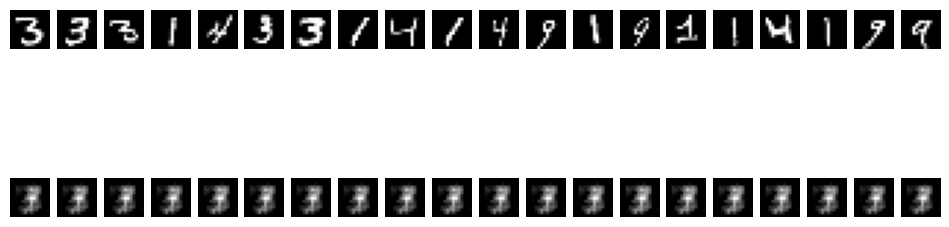

In [ ]:
# 5. Visualizing Original and Reconstructed Images
number_of_images = 5

test_loader = DataLoader(object_dataset, batch_size=1, shuffle=True)

reconstructed = []
test_imgs = []

for imgs in test_loader:
    img, _ = imgs    
    img = img.view(img.size(0), -1).to(device)
    test_imgs.append(img)
    output = model(img)
    reconstructed.append(output.unsqueeze(0))

reconstructed = torch.stack(reconstructed, dim=1)
test_imgs = torch.stack(test_imgs, dim=1)

# Convert back to image format for visualization
reconstructed = reconstructed.view(1, n, 14, 14).cpu().detach()
test_imgs = test_imgs.view(1, n, 14, 14)

# Save tensors
torch.save(test_imgs, os.path.join(f"./data_runs/{name_of_experiment}", "original.pt"))
torch.save(reconstructed, os.path.join(f"./data_runs/{name_of_experiment}", "reconstructed.pt"))


num_images = len(test_imgs[0])
fig, axes = plt.subplots(2, num_images, figsize=(12, 4))

for i in range(num_images):
    axes[0, i].imshow(test_imgs[0][i], cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[0][i], cmap='gray')
    axes[1, i].axis('off')

comparison_path = os.path.join(f"./data_runs/{name_of_experiment}", "comparison.png")
plt.savefig(comparison_path) 
plt.show()

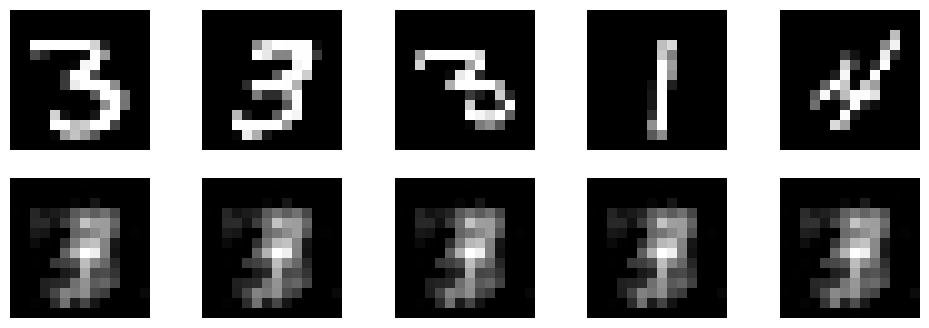

In [ ]:
fig, axes = plt.subplots(2, number_of_images, figsize=(12, 4))

for i in range(number_of_images):
    axes[0, i].imshow(test_imgs[0][i], cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[0][i], cmap='gray')
    axes[1, i].axis('off')

comparison_path = os.path.join(f"./data_runs/{name_of_experiment}", "comparison2.png")
plt.savefig(comparison_path) 
plt.show()

Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.


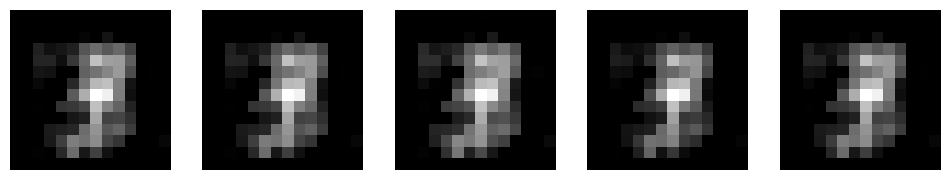

In [ ]:
number_of_images = 5
# Generate random latent vectors (e.g., 10 samples in a 3-dimensional latent space)
latent_vectors = torch.rand((number_of_images, 1, n_comblines[0]), device=device)# * 2 - 1

new_data = []
# Feed latent vectors into the decoder to generate new data
with torch.no_grad():
    for i in latent_vectors:
        output = model.forward_eval(i)
        new_data.append(output.unsqueeze(0))

new_data = torch.stack(new_data, dim=1)
torch.save(new_data, os.path.join(f"./data_runs/{name_of_experiment}", "new_data1.pt"))

# Reshape generated data to image format (batch_size, 1, 28, 28)
new_data_images = new_data.view(1, number_of_images, 14, 14).cpu()
# Plot the generated images

fig, axes = plt.subplots(1, number_of_images, figsize=(12, 4))

for i in range(number_of_images):
    axes[i].imshow(new_data_images[0][i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.savefig(f"./data_runs/{name_of_experiment}/new_image1.png")
plt.show()

Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.


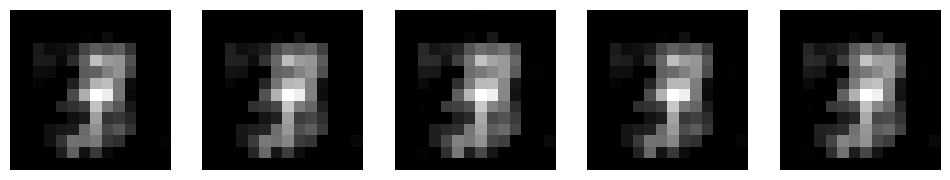

In [ ]:
# from MTP1000_LASERBLADE_API import MTP1000_LASERBLADE_API
# laser = MTP1000_LASERBLADE_API(ip="192.168.97.201")
# slot = 8
# channel = 2
# # Set laser power
# laser.set_power(slot, channel, 15.4)
# laser.set_output_state(slot, channel, "ON")
# laser.set_wavelength(slot, channel, 1546.005)

number_of_images = 5
# Generate random latent vectors (e.g., 10 samples in a 3-dimensional latent space)
latent_vectors = torch.rand((number_of_images, 1, n_comblines[0]), device=device)# * 2 - 1

new_data = []
# Feed latent vectors into the decoder to generate new data
with torch.no_grad():
    for i in latent_vectors:
        output = model.forward_eval(i)
        new_data.append(output.unsqueeze(0))

new_data = torch.stack(new_data, dim=1)
torch.save(new_data, os.path.join(f"./data_runs/{name_of_experiment}", "new_data2.pt"))

# Reshape generated data to image format (batch_size, 1, 28, 28)
new_data_images = new_data.view(1, number_of_images, 14, 14).cpu()
# Plot the generated images

fig, axes = plt.subplots(1, number_of_images, figsize=(12, 4))

for i in range(number_of_images):
    axes[i].imshow(new_data_images[0][i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.savefig(f"./data_runs/{name_of_experiment}/new_image_low_power.png")
plt.show()

In [ ]:
# === Disconnect ===
disconnect_delete_waveshaper()
osa.close_connection()

Disconnecting from waveshaper...   success
Deliting waveshaper...   success
Connection closed
